# Audio MFCC VGG19 Training Notebook (Stabilized)
This version fixes MFCC extraction, normalization, optimizer settings, and training stability.

In [ ]:

# =========================
# 1) Install + Imports
# =========================
!pip install -q augly librosa torchinfo h5py

import os, sys, copy, time, pickle, warnings
warnings.filterwarnings("ignore")

import h5py
import librosa
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

from google.colab import drive

# Mount Google Drive if needed
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Fix for augly / torchaudio compatibility
import torchaudio
class SoxPatch:
    @staticmethod
    def apply_effects_tensor(tensor, sample_rate, effects, channels_first=True):
        return tensor, sample_rate

if not hasattr(torchaudio, 'sox_effects'):
    torchaudio.sox_effects = SoxPatch()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.3/24.3 MB 104.6 MB/s eta 0:00:00
Mounted at /content/drive
Device: cuda


In [ ]:

# =========================
# 2) Clone Project Repo
# =========================
if not os.path.exists('/content/Final-year-project-2026'):
    !git clone https://github.com/mona0101/Final-year-project-2026.git

%cd /content/Final-year-project-2026


Cloning into 'Final-year-project-2026'...
remote: Enumerating objects: 255, done.
remote: Counting objects: 100% (106/106), done.
remote: Compressing objects: 100% (101/101), done.
remote: Total 255 (delta 44), reused 0 (delta 0), pack-reused 149 (from 2)
Receiving objects: 100% (255/255), 3.69 MiB | 19.37 MiB/s, done.
Resolving deltas: 100% (114/114), done.
/content/Final-year-project-2026


In [ ]:

# =========================
# 3) Config
# =========================
class Args:
    dataset_dir = '/content/drive/MyDrive/data'
    batch_size = 32
    num_workers = min(4, os.cpu_count())
    pin_memory = True

    feature_type = 'mfcc'
    modalities = ['audio']
    crop_size = 112

    # Audio feature settings
    target_sr = 16000
    n_mfcc = 40
    n_fft = 1024
    hop_length = 256
    segment_length = 0.25
    target_frames = 40

    # Training settings
    num_epochs = 10
    lr = 1e-5
    weight_decay = 1e-4
    patience = 4

args = Args()
print(vars(args))


{}


In [ ]:

# =========================
# 4) Dataset (Fixed MFCC Extraction)
# =========================
class DroneFusionDatasetH5(Dataset):
    def __init__(
        self,
        h5_path,
        transform=None,
        audio_feature_type='mfcc',
        modalities=['audio'],
        is_training=True,
        target_sr=16000,
        n_mfcc=40,
        n_fft=1024,
        hop_length=256,
        n_mels=64,
        segment_length=0.25,
        target_frames=40
    ):
        self.h5_path = h5_path
        self.transform = transform or {}
        self.audio_feature_type = audio_feature_type.lower()
        self.modalities = [m.lower() for m in modalities]
        self.is_training = is_training

        self.target_sr = target_sr
        self.n_mfcc = n_mfcc
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.n_mels = n_mels
        self.segment_length = segment_length
        self.target_frames = target_frames

        if not os.path.exists(self.h5_path):
            raise FileNotFoundError(f"HDF5 file not found at: {self.h5_path}")

        with h5py.File(self.h5_path, 'r') as f:
            self.length = len(f['labels'])

        print(f"Loaded {self.h5_path} with {self.length} samples")

    def __len__(self):
        return self.length

    def _fix_audio_length(self, waveform, sr):
        target_len = int(self.segment_length * sr)
        if len(waveform) < target_len:
            waveform = np.pad(waveform, (0, target_len - len(waveform)), mode='constant')
        else:
            waveform = waveform[:target_len]
        return waveform

    def _extract_audio_feature(self, waveform, sr):
        waveform = waveform.astype(np.float32)

        # Fix audio length before resampling
        waveform = self._fix_audio_length(waveform, sr)

        # True resampling instead of waveform[::3]
        if sr != self.target_sr:
            waveform = librosa.resample(waveform, orig_sr=sr, target_sr=self.target_sr)
            sr = self.target_sr

        # Amplitude normalization
        max_val = np.max(np.abs(waveform))
        if max_val > 0:
            waveform = waveform / max_val

        if self.audio_feature_type == 'mfcc':
            feat = librosa.feature.mfcc(
                y=waveform,
                sr=sr,
                n_mfcc=self.n_mfcc,
                n_fft=self.n_fft,
                hop_length=self.hop_length
            )
        elif self.audio_feature_type == 'logmel':
            mel = librosa.feature.melspectrogram(
                y=waveform,
                sr=sr,
                n_mels=self.n_mels,
                n_fft=self.n_fft,
                hop_length=self.hop_length,
                power=2.0
            )
            feat = librosa.power_to_db(mel, ref=np.max)
        else:
            raise ValueError(f"Unsupported audio_feature_type: {self.audio_feature_type}")

        # Pad / crop to fixed width
        if feat.shape[1] < self.target_frames:
            pad_width = self.target_frames - feat.shape[1]
            feat = np.pad(feat, ((0, 0), (0, pad_width)), mode='constant')
        else:
            feat = feat[:, :self.target_frames]

        # Feature normalization
        feat = (feat - feat.mean()) / (feat.std() + 1e-6)
        feat = np.clip(feat, -5, 5)

        return torch.tensor(feat, dtype=torch.float32).unsqueeze(0)

    def __getitem__(self, idx):
        with h5py.File(self.h5_path, 'r') as f:
            label = int(f['labels'][idx])

            outputs = []

            if 'audio' in self.modalities:
                # Try common key names
                if 'audio' in f:
                    waveform = f['audio'][idx]
                elif 'audio_data' in f:
                    waveform = f['audio_data'][idx]
                else:
                    raise KeyError("Could not find audio data key in HDF5 file.")

                # Try common sample-rate key names
                if 'sample_rate' in f:
                    sr = int(f['sample_rate'][idx]) if np.ndim(f['sample_rate']) > 0 else int(f['sample_rate'][()])
                elif 'sr' in f:
                    sr = int(f['sr'][idx]) if np.ndim(f['sr']) > 0 else int(f['sr'][()])
                else:
                    sr = 48000  # fallback if not stored

                audio_tensor = self._extract_audio_feature(waveform, sr)
                outputs.append(audio_tensor)

            outputs.append(torch.tensor(label, dtype=torch.float32))
            return tuple(outputs)


In [ ]:

# =========================
# 5) Build DataLoaders
# =========================
train_h5 = os.path.join(args.dataset_dir, 'Drone_Train.h5')
val_h5   = os.path.join(args.dataset_dir, 'Drone_Validation.h5')
test_h5  = os.path.join(args.dataset_dir, 'Drone_Test.h5')

for p in [train_h5, val_h5, test_h5]:
    print(p, "->", os.path.exists(p))

train_dataset = DroneFusionDatasetH5(
    train_h5,
    audio_feature_type=args.feature_type,
    modalities=args.modalities,
    is_training=True,
    target_sr=args.target_sr,
    n_mfcc=args.n_mfcc,
    n_fft=args.n_fft,
    hop_length=args.hop_length,
    segment_length=args.segment_length,
    target_frames=args.target_frames
)

val_dataset = DroneFusionDatasetH5(
    val_h5,
    audio_feature_type=args.feature_type,
    modalities=args.modalities,
    is_training=False,
    target_sr=args.target_sr,
    n_mfcc=args.n_mfcc,
    n_fft=args.n_fft,
    hop_length=args.hop_length,
    segment_length=args.segment_length,
    target_frames=args.target_frames
)

test_dataset = DroneFusionDatasetH5(
    test_h5,
    audio_feature_type=args.feature_type,
    modalities=args.modalities,
    is_training=False,
    target_sr=args.target_sr,
    n_mfcc=args.n_mfcc,
    n_fft=args.n_fft,
    hop_length=args.hop_length,
    segment_length=args.segment_length,
    target_frames=args.target_frames
)

loaders = {
    'train': DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True,
                        num_workers=args.num_workers, pin_memory=args.pin_memory),
    'val':   DataLoader(val_dataset, batch_size=args.batch_size, shuffle=False,
                        num_workers=args.num_workers, pin_memory=args.pin_memory),
    'test':  DataLoader(test_dataset, batch_size=args.batch_size, shuffle=False,
                        num_workers=args.num_workers, pin_memory=args.pin_memory),
}

# Check one batch
batch = next(iter(loaders['train']))
print("Batch X shape:", batch[0].shape)
print("Batch y shape:", batch[-1].shape)


/content/drive/MyDrive/data/Drone_Train.h5 -> True
/content/drive/MyDrive/data/Drone_Validation.h5 -> True
/content/drive/MyDrive/data/Drone_Test.h5 -> True
Loaded /content/drive/MyDrive/data/Drone_Train.h5 with 8480 samples
Loaded /content/drive/MyDrive/data/Drone_Validation.h5 with 1280 samples
Loaded /content/drive/MyDrive/data/Drone_Test.h5 with 1320 samples
Batch X shape: torch.Size([32, 1, 40, 40])
Batch y shape: torch.Size([32])


In [ ]:

# =========================
# 6) Optional: Class Imbalance Check
# =========================
all_train_labels = []
for _, labels in loaders['train']:
    all_train_labels.extend(labels.numpy().tolist())

all_train_labels = np.array(all_train_labels)
num_pos = np.sum(all_train_labels == 1)
num_neg = np.sum(all_train_labels == 0)

print("Train class counts -> Neg:", num_neg, "Pos:", num_pos)

pos_weight_value = num_neg / max(num_pos, 1)
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32).to(device)
print("pos_weight =", pos_weight.item())


Train class counts -> Neg: 3760 Pos: 4720
pos_weight = 0.7966101765632629


In [ ]:

# =========================
# 7) Model
# =========================
import torch
import torch.nn as nn
import torchvision.models as tv_models

class GlobalPooling2D(nn.Module):
    def __init__(self):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

    def forward(self, x):
        return self.pool(x).view(x.size(0), -1)


class AudioVGG19TRIDENT(nn.Module):
    def __init__(self):
        super().__init__()

        vgg = tv_models.vgg19(weights=None)

        # تعديل أول layer عشان input يكون 1 channel
        vgg.features[0] = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1)

        self.features = vgg.features

        self.global_pool = GlobalPooling2D()

        # 🔥 Dropout + BN + Dropout (أفضل من واحد فقط)
        self.bn = nn.BatchNorm1d(512)
        self.dropout1 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(512, 128)

        self.relu = nn.ReLU()
        self.dropout2 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        x = self.features(x)

        x = self.global_pool(x)

        x = self.bn(x)

        x = self.dropout1(x)
        x = self.fc1(x)

        x = self.relu(x)

        x = self.dropout2(x)
        x = self.fc2(x)

        return x.squeeze(1)

In [ ]:

# =========================
# 8) Loss + Optimizer + Scheduler
# =========================
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=args.lr,
    weight_decay=args.weight_decay
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

print("Optimizer and scheduler ready")


Optimizer and scheduler ready


In [ ]:

# =========================
# 9) Training / Evaluation Functions
# =========================
def plot_training_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.title('Loss vs Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], label='Train Acc')
    plt.plot(epochs, history['val_acc'], label='Val Acc')
    plt.title('Accuracy vs Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

def print_classification_report(y_true, y_pred, name='Dataset'):
    print(f"\n{name} Classification Report:")
    print(classification_report(y_true, y_pred, digits=4))

def test_unimodal(model, dataloader, device, dataset_name='Test', modal_num=0):
    model.eval()
    all_probs, all_preds, all_labels = [], [], []
    total_time = 0.0
    total_samples = 0

    with torch.no_grad():
        for batch in tqdm(dataloader, desc=f"Testing {dataset_name}", leave=False):
            inputs = batch[modal_num].to(device).float()
            labels = batch[-1].to(device).float().view(-1)

            start_time = time.time()
            outputs = model(inputs)
            total_time += (time.time() - start_time)

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).long()

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            total_samples += inputs.size(0)

    y_true = np.array(all_labels).astype(int)
    y_pred = np.array(all_preds).astype(int)
    y_prob = np.array(all_probs)

    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'y_true': y_true,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'avg_ms': (total_time / max(total_samples, 1)) * 1000,
        'fps': total_samples / max(total_time, 1e-8)
    }
    return metrics

def train_unimodal(model, dataloaders, device, optimizer, criterion, scheduler=None,
                   num_epochs=15, modal_num=0, patience=4):
    history = {k: [] for k in ['train_loss', 'val_loss', 'train_acc', 'val_acc']}
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    patience_counter = 0

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            all_preds, all_labels = [], []

            for batch in tqdm(dataloaders[phase], desc=phase.upper(), leave=False):
                inputs = batch[modal_num].to(device).float()
                labels = batch[-1].to(device).float().view(-1)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs).view(-1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)

                probs = torch.sigmoid(outputs)
                preds = (probs > 0.5).long()
                all_preds.append(preds.detach().cpu())
                all_labels.append(labels.detach().cpu().long())

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            y_true = torch.cat(all_labels).numpy()
            y_pred = torch.cat(all_preds).numpy()
            epoch_acc = accuracy_score(y_true, y_pred)

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc)

            print(f"{phase.upper()} -> Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

            if phase == 'val':
                if scheduler is not None:
                    scheduler.step(epoch_loss)

                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    patience_counter = 0
                    print(f"New Best Model! Val Acc: {best_acc:.4f}")
                else:
                    patience_counter += 1
                    print(f"No improvement. patience = {patience_counter}/{patience}")

        current_lr = optimizer.param_groups[0]['lr']
        print("Current LR:", current_lr)

        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    model.load_state_dict(best_model_wts)
    print(f"\nBest Val Acc: {best_acc:.4f}")
    return model, history



Epoch 1/10


TRAIN -> Loss: 0.1114 | Acc: 0.9512


VAL -> Loss: 0.1816 | Acc: 0.9164
New Best Model! Val Acc: 0.9164
Current LR: 1e-05

Epoch 2/10


TRAIN -> Loss: 0.0907 | Acc: 0.9608


VAL -> Loss: 0.3407 | Acc: 0.8828
No improvement. patience = 1/4
Current LR: 1e-05

Epoch 3/10


...

VAL -> Loss: 0.2425 | Acc: 0.9219
No improvement. patience = 2/4
Current LR: 5e-06

Epoch 6/10


TRAIN -> Loss: 0.0464 | Acc: 0.9815


VAL -> Loss: 0.4268 | Acc: 0.8969
No improvement. patience = 3/4
Current LR: 5e-06

Epoch 7/10


TRAIN -> Loss: 0.0403 | Acc: 0.9840


VAL -> Loss: 0.4997 | Acc: 0.9000
No improvement. patience = 4/4
Current LR: 2.5e-06
Early stopping triggered at epoch 7

Best Val Acc: 0.9242


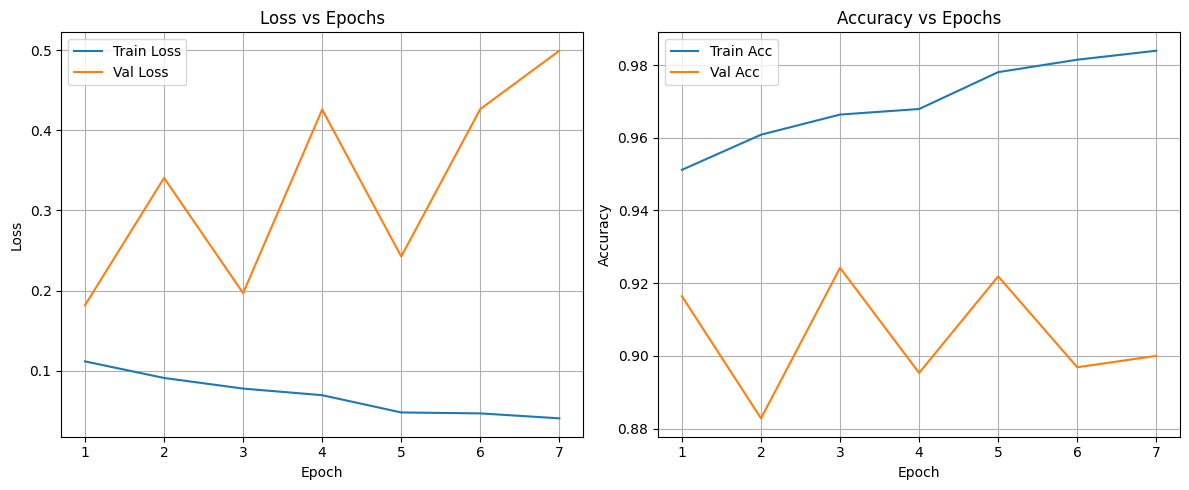

In [ ]:

# =========================
# 10) Run Training
# =========================
model, history = train_unimodal(
    model=model,
    dataloaders=loaders,
    device=device,
    optimizer=optimizer,
    criterion=criterion,
    scheduler=scheduler,
    num_epochs=args.num_epochs,
    modal_num=0,
    patience=args.patience
)

plot_training_history(history)



Train Metrics
Accuracy : 0.9797
Precision: 0.988
Recall   : 0.9754
F1       : 0.9817
Avg ms   : 0.0223
FPS      : 44900.7725

Validation Metrics
Accuracy : 0.9242
Precision: 0.9313
Recall   : 0.9487
F1       : 0.9399
Avg ms   : 0.0246
FPS      : 40576.1316

Test Metrics
Accuracy : 0.9167
Precision: 0.9517
Recall   : 0.9155
F1       : 0.9333
Avg ms   : 0.0236
FPS      : 42365.0861

Train Classification Report:
              precision    recall  f1-score   support

           0     0.9696    0.9851    0.9773      3760
           1     0.9880    0.9754    0.9817      4720

    accuracy                         0.9797      8480
   macro avg     0.9788    0.9803    0.9795      8480
weighted avg     0.9798    0.9797    0.9797      8480



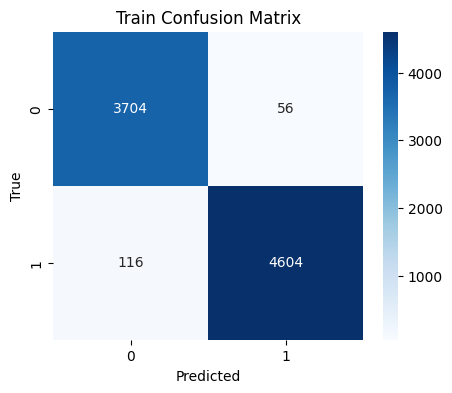


Validation Classification Report:
              precision    recall  f1-score   support

           0     0.9118    0.8833    0.8974       480
           1     0.9313    0.9487    0.9399       800

    accuracy                         0.9242      1280
   macro avg     0.9216    0.9160    0.9186      1280
weighted avg     0.9240    0.9242    0.9240      1280



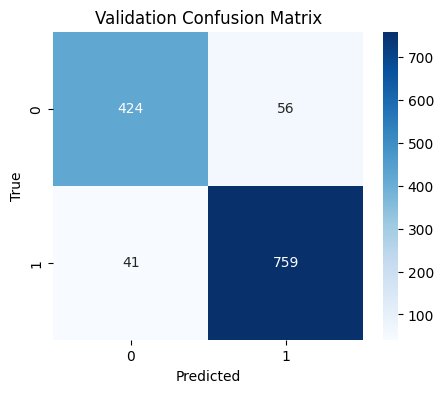


Test Classification Report:
              precision    recall  f1-score   support

           0     0.8613    0.9187    0.8891       480
           1     0.9517    0.9155    0.9333       840

    accuracy                         0.9167      1320
   macro avg     0.9065    0.9171    0.9112      1320
weighted avg     0.9189    0.9167    0.9172      1320



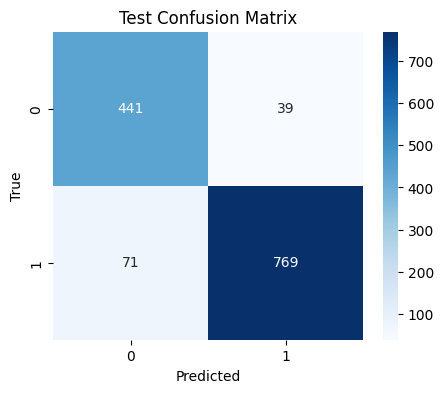

In [ ]:

# =========================
# 11) Evaluate on Train / Val / Test
# =========================
train_metrics = test_unimodal(model, loaders['train'], device, dataset_name='Train', modal_num=0)
val_metrics   = test_unimodal(model, loaders['val'],   device, dataset_name='Validation', modal_num=0)
test_metrics  = test_unimodal(model, loaders['test'],  device, dataset_name='Test', modal_num=0)

for name, metrics in [('Train', train_metrics), ('Validation', val_metrics), ('Test', test_metrics)]:
    print(f"\n{name} Metrics")
    print("Accuracy :", round(metrics['accuracy'], 4))
    print("Precision:", round(metrics['precision'], 4))
    print("Recall   :", round(metrics['recall'], 4))
    print("F1       :", round(metrics['f1'], 4))
    print("Avg ms   :", round(metrics['avg_ms'], 4))
    print("FPS      :", round(metrics['fps'], 4))

print_classification_report(train_metrics['y_true'], train_metrics['y_pred'], 'Train')
plot_confusion_matrix(train_metrics['y_true'], train_metrics['y_pred'], 'Train Confusion Matrix')

print_classification_report(val_metrics['y_true'], val_metrics['y_pred'], 'Validation')
plot_confusion_matrix(val_metrics['y_true'], val_metrics['y_pred'], 'Validation Confusion Matrix')

print_classification_report(test_metrics['y_true'], test_metrics['y_pred'], 'Test')
plot_confusion_matrix(test_metrics['y_true'], test_metrics['y_pred'], 'Test Confusion Matrix')


In [ ]:

# =========================
# 12) Save Model + Results
# =========================
save_dir = "/content/drive/MyDrive/UniModel_result"
os.makedirs(save_dir, exist_ok=True)

model_name = "Audio_MFCC_VGG_fixed"

weights_path = os.path.join(save_dir, f"{model_name}_weights.pth")
torch.save(model.state_dict(), weights_path)
print("Saved model weights ->", weights_path)

results = {
    'history': history,
    'train_metrics': train_metrics,
    'val_metrics': val_metrics,
    'test_metrics': test_metrics,
    'detection_time': {
        'avg_time_per_sample': test_metrics['avg_ms'],
        'fps': test_metrics['fps']
    },
    'config': vars(args)
}

results_path = os.path.join(save_dir, f"{model_name}_results.pkl")
with open(results_path, 'wb') as f:
    pickle.dump(results, f)

print("Saved results ->", results_path)


Saved model weights -> /content/drive/MyDrive/UniModel_result/Audio_MFCC_VGG_fixed_weights.pth
Saved results -> /content/drive/MyDrive/UniModel_result/Audio_MFCC_VGG_fixed_results.pkl


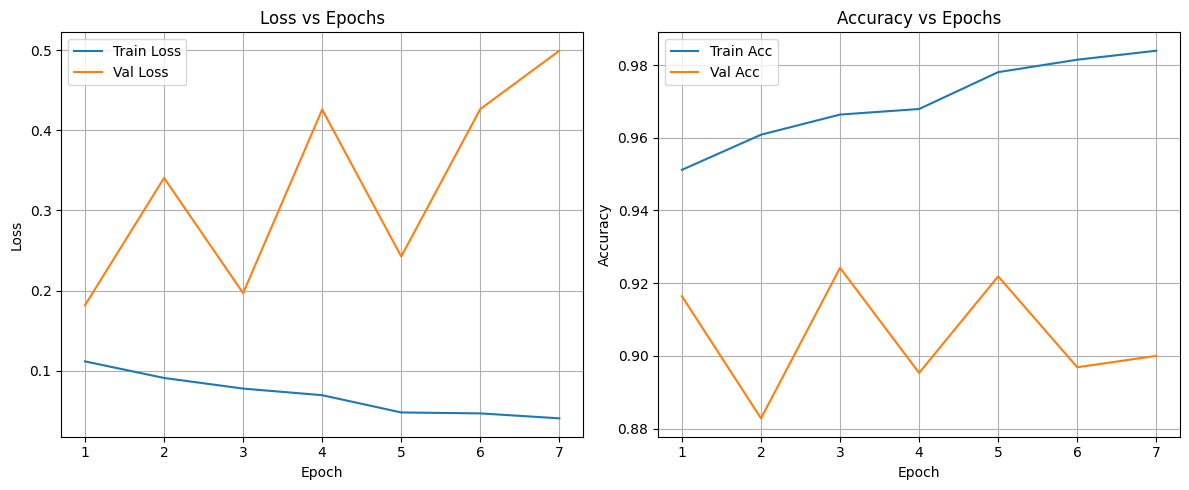

In [ ]:

# =========================
# 13) Reload Saved Results and Plot Again
# =========================
results_path = "/content/drive/MyDrive/UniModel_result/Audio_MFCC_VGG_fixed_results.pkl"

with open(results_path, 'rb') as f:
    results = pickle.load(f)

history = results['history']
plot_training_history(history)
